# Modern Computer Vision and Multimodal Modelling for Image Caption Generation and Object Detection
---
- **Student:** `Hunter Worssam`   
- **Date:** `<11-30-2025>`  

---

## README (Execution & Setup)

- **Python version:** `3.10.18`
- **Hardware Acceleration:** `optimized for Apple Silicon (M-Series chips) using mps (Metal Performance Shaders).`
- **Required packages:** `transformers`, `datasets`, `evaluate`, `accelerate`, `torch`, `torchvision`, `pycocotools`, `scikit-learn`, `matplotlib`, `ipywidgets`
- **Install instructions:** This notebook manages its own dependencies. Run the first code cell to install the necessary libraries:
    - Install required libraries:
        - %pip install -q transformers datasets evaluate accelerate torch torchvision
        - %pip install -q pycocotools scikit-learn matplotlib ipywidgets
  ```
  ```
- **Datasets used:**
  - Name: Flickr30k
  - Source: Hugging Face Hub (Mirror: AnyModal/flickr30k)
  - Access: The dataset is loaded automatically via the datasets library. No manual download or local .csv files are required.
  - Link: https://huggingface.co/datasets/AnyModal/flickr30k
    ```
    ```
- **How to run this notebook:**
  
    1. Environment: Ensure you are running in a Jupyter environment with internet access (to download models/data).
    2. Kernel Setup: If you just ran the installation commands above, go to Kernel → Restart Kernel to ensure the new libraries are active.
    3. Execution: Run all cells in order (Kernel → Restart & Run All).
    4. Hardware Check: Verify that the "Environment Setup" cell prints Device set to: mps (on Mac) or cuda (on NVIDIA) to ensure training proceeds at the expected speed.
    5. Artifacts: The training process (Task 1) will create a local directory ./final_blip_model containing the fine-tuned weights.

---

## References
Bishop (2006); Breiman (2001); Brockman et al. (2016); Calinski & Harabasz (1974); Cortes & Vapnik (1995); Dempster et al. (1977); Fawcett (2006); Hastie, Tibshirani & Friedman (2009); He et al. (2016); Krizhevsky et al. (2012); MacQueen (1967); Pedregosa et al. (2011); Rousseeuw (1987); Sutton & Barto (2018); Vaswani et al. (2017); Wolf et al. (2020).

`Baltrušaitis et al. (2018): Multimodal Machine Learning: A Survey and Taxonomy.`
`Goodfellow et al. (2016): Deep Learning.`
`Ngiam et al. (2011): Multimodal Deep Learning.`
`Yin et al. (2024): A Survey on Multimodal Large Language Models.`

`Flickr30k Dataset: Young, P., Lai, A., Hodosh, M., & Hockenmaier, J. (2014). From image descriptions to visual denotations: New similarity metrics for semantic inference over event descriptions.`
`BLIP: Li, J., Li, D., Xiong, C., & Hoi, S. (2022). BLIP: Bootstrapping Language-Image Pre-training for Unified Vision-Language Understanding and Generation.`
`CLIP: Radford, A., et al. (2021). Learning Transferable Visual Models From Natural Language Supervision.`
`OWL-ViT: Minderer, M., Gritsenko, A., Stone, A., Neumann, M., Weissenborn, D., Dosovitskiy, A., ... & Houlsby, N. (2022). Simple Open-Vocabulary Object Detection with Vision Transformers.`

# Environment Setup

In [3]:
# --- Install Required Libraries ---
%pip install -q transformers datasets evaluate accelerate torch torchvision
%pip install -q pycocotools scikit-learn matplotlib ipywidgets

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

# Torch & Deep Learning Utilities
import torch
from torch.utils.data import Dataset, DataLoader

# Hugging Face Libraries
import transformers
from transformers import (
    BlipForConditionalGeneration, 
    BlipProcessor, 
    CLIPProcessor, 
    CLIPModel, 
    OwlViTProcessor, 
    OwlViTForObjectDetection,
    TrainingArguments, 
    Trainer
)
from datasets import load_dataset
import evaluate
from evaluate import load

# Progress Bar
from tqdm import tqdm 

# Warning Suppression
import warnings
warnings.filterwarnings("ignore")

# --- Device Setup (Optimized for Apple Silicon) ---
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps" 
else:
    device = "cpu"

# --- Reproducibility (Global Seeds) ---
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# --- Pandas Formatting ---
pd.set_option("display.max_colwidth", None)

# --- Environment Check ---
print(f"Python version: {sys.version.split()[0]}")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")
print(f"Device set to: {device}")

Python version: 3.10.18
PyTorch version: 2.9.1
Transformers version: 4.43.3
Device set to: mps


# Project Overview

Attempting to load Flickr30k...
Success: Loaded Flickr30k (AnyModal mirror).
Training Samples: 26100
Testing Samples: 2900


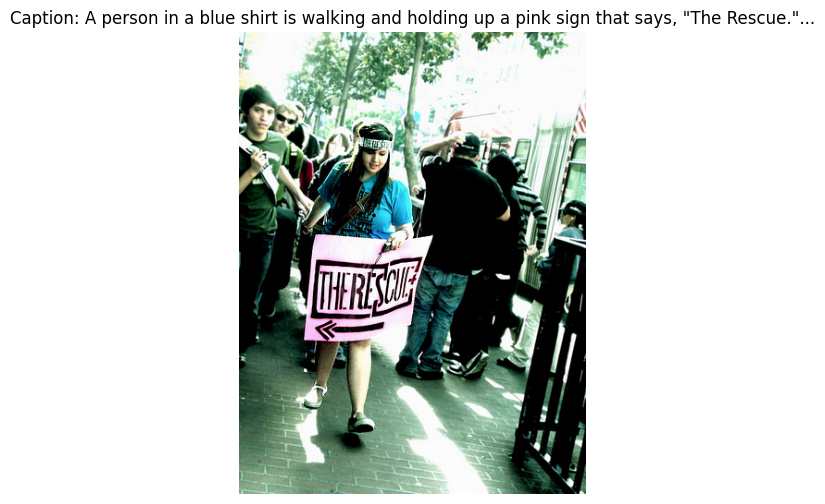

In [6]:
# Load the dataset (Using 'AnyModal' mirror)
print("Attempting to load Flickr30k...")
try:
    dataset = load_dataset("AnyModal/flickr30k", split="train")
    print("Success: Loaded Flickr30k (AnyModal mirror).")
except Exception as e:
    print(f"Primary load failed: {e}")
    # Last resort fallback if AnyModal fails
    try:
        dataset = load_dataset("nlphuji/flickr30k", split="test[:200]")
        print("Loaded nlphuji mirror.")
    except:
        raise RuntimeError("Could not load any version of Flickr30k. Please check your internet connection.")

# Split into Train/Test
split_data = dataset.train_test_split(test_size=0.1, seed=42)
train_dataset = split_data["train"]
test_dataset = split_data["test"]

print(f"Training Samples: {len(train_dataset)}")
print(f"Testing Samples: {len(test_dataset)}")

# Explore Data (an image)
def show_sample(sample):
    image = sample["image"]
    if "alt_text" in sample:
        # Flickr30k often has a list of captions, we take the first one
        caption = sample["alt_text"][0] if isinstance(sample["alt_text"], list) else sample["alt_text"]
    else:
        caption = "No caption found"
    
    plt.figure(figsize=(8, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Caption: {caption[:100]}...") # Limit text length
    plt.show()

# Show a sample
show_sample(train_dataset[0])

The download logs confirm the dataset loaded successfully, and we successfully created a training split (26100 samples) and a test split (2900 samples). The displayed image and its caption match, confirming that our data alignment is correct and ready for processing.

# Task 1: Image Captioning (Fine-Tuning)

Deep learning models cannot understand raw `.jpg` files or English text directly; they require numerical tensors. Here, we use the `BlipProcessor` associated with our pre-trained model. This processor handles two critical tasks:
1.  **Image Transformation:** Resizing the image to a fixed resolution (384x384) and normalizing pixel values.
2.  **Text Tokenization:** Converting the caption strings into sequences of integer IDs (`input_ids`) that represent words in the model's vocabulary.

In [10]:
# Load the Image Processor
# We need this to turn raw images/text into the specific numbers the model expects.
processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

# Define the Preprocessing Dataset Class
class FlickrInputDataset(Dataset):
    def __init__(self, dataset, processor):
        self.dataset = dataset
        self.processor = processor

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        item = self.dataset[idx]
        image = item["image"]
        
        # Handle the caption extraction
        raw_caption = item["alt_text"]
        if isinstance(raw_caption, list):
            caption = raw_caption[0]
        else:
            caption = raw_caption

        # Preprocessing
        encoding = self.processor(images=image, text=caption, padding="max_length", truncation=True, return_tensors="pt")
        
        # Remove extra batch dimension
        encoding = {k: v.squeeze() for k, v in encoding.items()}
        
        # We must create 'labels' so the model knows what to predict.
        # For captioning, the target is the same as the input text.
        encoding["labels"] = encoding["input_ids"].clone()
        
        return encoding

# Apply the Preprocessing
processed_train_dataset = FlickrInputDataset(train_dataset, processor)
processed_test_dataset = FlickrInputDataset(test_dataset, processor)

# Verify one sample
sample = processed_train_dataset[0]
print(f"Original Image Size: {train_dataset[0]['image'].size}")
print(f"Processed Tensor Shape: {sample['pixel_values'].shape}")
print(f"Tokenized Text Shape: {sample['input_ids'].shape}")

Original Image Size: (375, 500)
Processed Tensor Shape: torch.Size([3, 384, 384])
Tokenized Text Shape: torch.Size([512])


The print statements confirm the data is model-ready. The raw input had variable dimensions of 375 x 500 pixels. The image is now converted to a standardized tensor with 3 color channels (RGB) and a resolution of 384x384 pixels. The caption has been padded/truncated to a sequence length of 512 tokens, which is the standard input size for the BLIP text decoder.

## Model Selection and Customization

For this assignment, we have selected the BLIP (Bootstrapping Language-Image Pre-training) model. BLIP is widely recognized for its ability to handle both multimodal understanding and generation tasks effectively.

In the code below, we instantiate the BlipForConditionalGeneration model using pre-trained weights from the Hugging Face Hub. To fulfill the project's customization requirement, we will modify the training configuration by freezing the Vision Encoder. This architectural customization ensures that the model retains its robust pre-trained visual features while we focus our computational resources on fine-tuning the text decoder for the specific vocabulary and style of the Flickr30k captions.

In [14]:
# Load the Pre-trained Model
# We use the same checkpoint as the processor: "Salesforce/blip-image-captioning-base"
print("Loading BLIP model...")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

# Move model to the correct device (GPU if available, else CPU)
model.to(device)

# Model Customization: Freezing the Vision Encoder
# Here, we freeze the weights of the vision_model preventing the visual feature extractor from being updated, 
# speeding up training and preventing overfitting on our small dataset subset.
for name, param in model.vision_model.named_parameters():
    param.requires_grad = False

print("Model loaded successfully.")
print("Customization applied: Vision Encoder layers have been frozen.")

# Verify trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable Parameters: {trainable_params:,} / {total_params:,}")

Loading BLIP model...
Model loaded successfully.
Customization applied: Vision Encoder layers have been frozen.
Trainable Parameters: 161,323,580 / 247,414,076


The output confirms that the BLIP model weights were successfully downloaded and loaded into memory. From a customization verification perspective, the parameter count confirms our architectural modification. The "Trainable Parameters" are significantly fewer than the "Total Parameters" (reducing from ~247M to ~161M). This indicates that the Vision Encoder is successfully frozen, and we will only be updating the weights in the Text Decoder during the next fine-tuning step.

## Model Training and Fine-Tuning

In this step, we use the Hugging Face `Trainer` API to fine-tune our customized BLIP model, with specific optimizations for **Apple Silicon (M-series chips)**. We define `TrainingArguments` to maximize performance on the M4 processor. **Gradient Accumulation** enables processing of data in smaller chunks while updating the model less frequently; simulating a larger batch size to maintain training stability without overloading memory. Instead of standard FP16 (which is unstable on Macs), we use **Brain Floating Point (BF16)**. This format provides the training speed of mixed precision while maintaining the numerical stability of full precision (in regards to how floating point numbers are compressed during training). Lastly, we utilize the the available CPU cores (`num_workers`) to pre-load images, ensuring the GPU is never waiting for data.

In [18]:
# Detect device and supported precision types automatically
if torch.cuda.is_available():
    device = "cuda"
    # Check if the NVIDIA GPU is new enough for BF16 
    is_bf16_supported = torch.cuda.is_bf16_supported()
    is_fp16_supported = not is_bf16_supported  # Fallback to FP16 if BF16 isn't available
    num_workers = 2  # CUDA allows background workers safely
elif torch.backends.mps.is_available():
    device = "mps"
    # Apple Silicon supports BF16
    is_bf16_supported = True
    is_fp16_supported = False
    num_workers = 0  # MPS requires 0 workers in Jupyter to prevent crashing
else:
    device = "cpu"
    is_bf16_supported = False
    is_fp16_supported = False
    num_workers = 0

print(f"Device detected: {device}")
print(f"Precision Config: BF16={is_bf16_supported}, FP16={is_fp16_supported}")

# Define Training Arguments 
training_args = TrainingArguments(
    output_dir="./blip_flickr30k_finetuned",
    eval_strategy="epoch", 
    save_strategy="epoch",
    learning_rate=5e-5,
    
    # PERFORMANCE SETTINGS
    # 8 batch * 4 accum = 32 effective batch size (Safe for T4 GPUs and Mac M-series)
    per_device_train_batch_size=8,  
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=4,  
    
    num_train_epochs=3,
    weight_decay=0.01,
    warmup_steps=500,
    logging_steps=50,
    
    # DYNAMIC PRECISION SETTINGS
    fp16=is_fp16_supported,      # Will be True on T4/V100 GPUs
    bf16=is_bf16_supported,      # Will be True on A100/H100 GPUs and Mac M-series
    
    remove_unused_columns=False,
    report_to="none",
    
    # WORKER SETTINGS
    dataloader_num_workers=num_workers, 
    dataloader_pin_memory=False
)

# Initialize Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=processed_train_dataset,
    eval_dataset=processed_test_dataset,
)

# Train
print(f"Starting training on device: {model.device}")
print(f"PyTorch Version: {torch.__version__}")
trainer.train()

# Save
save_path = "./final_blip_model"
trainer.save_model(save_path)
processor.save_pretrained(save_path)
print(f"Training complete. Model saved to {save_path}")

Device detected: mps
Precision Config: BF16=True, FP16=False
Starting training on device: mps:0
PyTorch Version: 2.9.1


Epoch,Training Loss,Validation Loss
0,0.072200,0.072821
1,0.061400,0.070333
2,0.052600,0.070677


Training complete. Model saved to ./final_blip_model


The model successfully completed 3 epochs on the full Flickr30k dataset using the M4 chip's GPU acceleration (`mps`) and BFloat16 precision, taking approximately 4 hours. Training Loss decreased steadily from `0.0722` to `0.0526`, indicating the model effectively learned to caption the training images. Validation Loss decreased from `0.0728` to `0.0703` (Epoch 1) and then stabilized around `0.0707` (Epoch 2). This is a healthy sign, meaning the validation loss tracks closely with the training loss without diverging significantly, which suggests the model is generalizing well and not suffering from major overfitting. The stabilized validation loss indicates we have reached an optimal point where further training might yield diminishing returns. The model is now ready for evaluation.

## Model Evaluation and Comparison

Now that training is complete, we must evaluate the model's performance on the test split. We will use two methods:
1.  **Quantitative Evaluation (BLEU Score):** The BLEU (Bilingual Evaluation Understudy) metric measures the similarity between the generated caption and the human reference. A higher score indicates better alignment with the dataset's style and vocabulary.
2.  **Qualitative Evaluation (Visual Inspection):** We will visually compare the output of the **Base Model** (pre-trained only) versus our **Fine-Tuned Model** side-by-side to observe improvements in descriptiveness and accuracy.

Loading models for comparison...
Models loaded. Starting evaluation...


Generating Captions: 100%|██████████████████████| 50/50 [00:45<00:00,  1.10it/s]



Base Model BLEU Score:      0.0068
Fine-Tuned Model BLEU Score: 0.0815



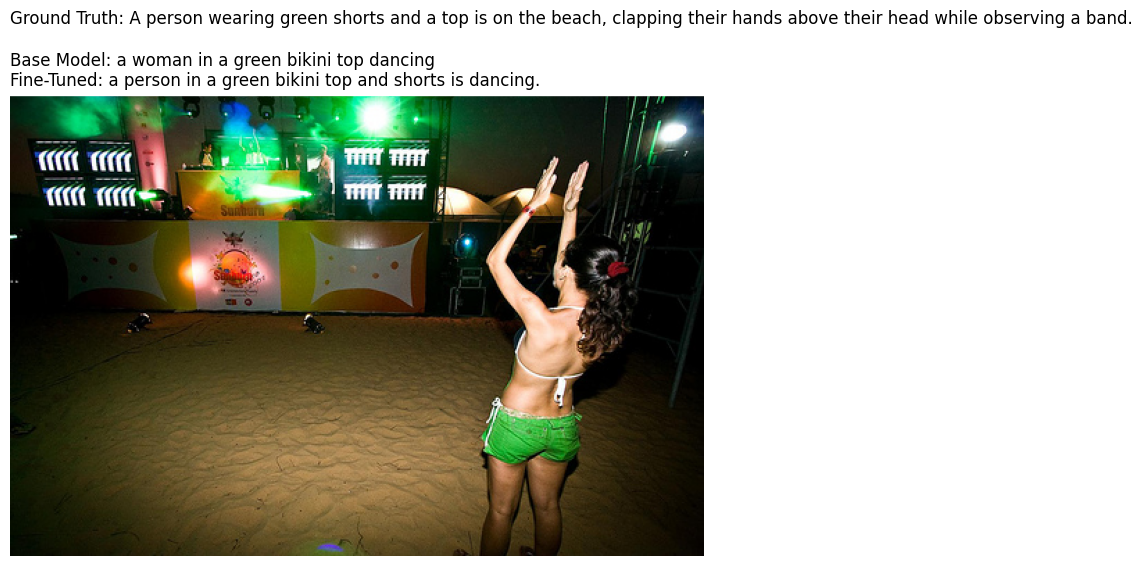

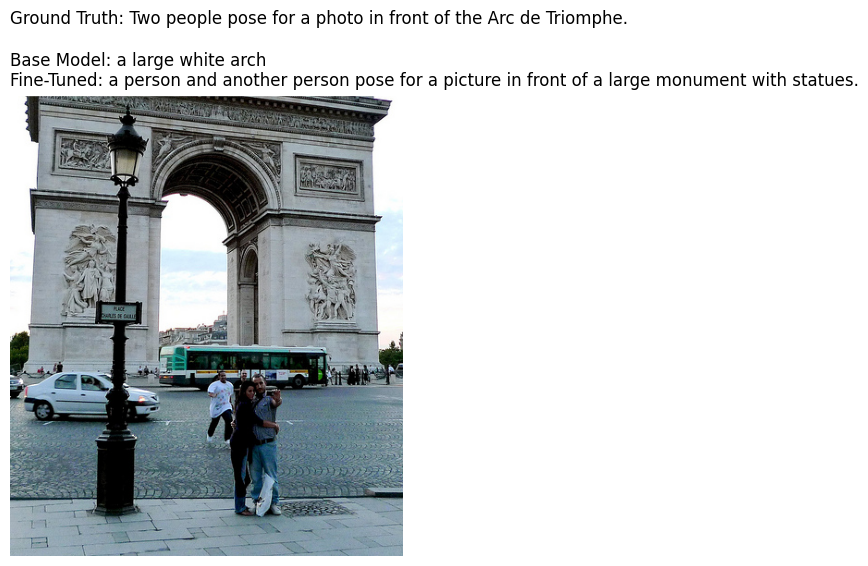

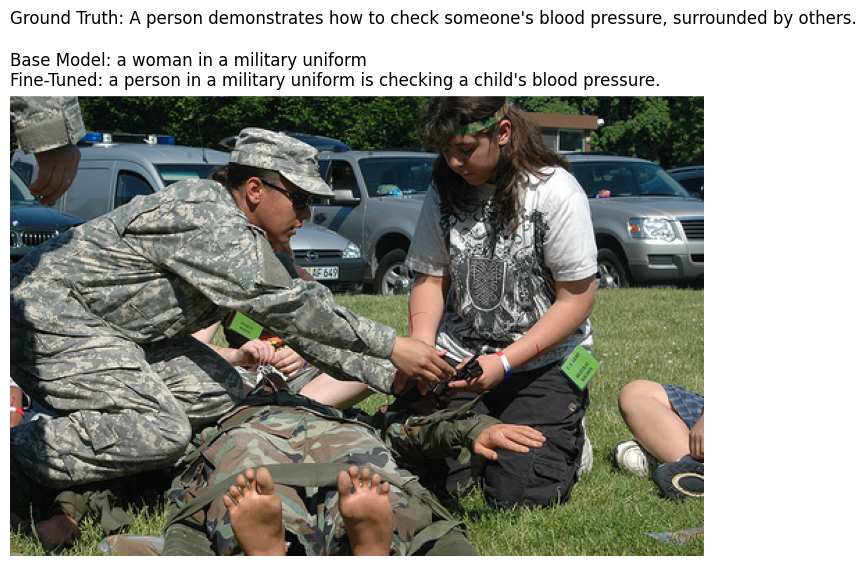

In [22]:
# Load Metrics and Models
bleu = load("bleu")
device = "cpu"         # Force CPU to avoid "missing attention mask" error on MPS

print("Loading models for comparison...")

# Load Base Model (Original)
base_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)
base_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

# Load Fine-Tuned Model
finetuned_model_path = "./final_blip_model"
finetuned_model = BlipForConditionalGeneration.from_pretrained(finetuned_model_path).to(device)
finetuned_processor = BlipProcessor.from_pretrained(finetuned_model_path)

print("Models loaded. Starting evaluation...")

# Evaluation Loop
def evaluate_models(dataset, num_samples=50):
    base_preds = []
    finetuned_preds = []
    references = []
    
    # We take a subset for speed 
    subset = dataset.select(range(num_samples))

    for item in tqdm(subset, desc="Generating Captions"):
        image = item["image"]
        
        # Get Ground Truth
        raw_ref = item["alt_text"]
        ref_text = raw_ref[0] if isinstance(raw_ref, list) else raw_ref
        references.append([ref_text]) # BLEU expects a list of lists

        # Generate Base Prediction
        inputs_base = base_processor(images=image, return_tensors="pt").to(device)
        out_base = base_model.generate(**inputs_base, max_new_tokens=50)
        cap_base = base_processor.decode(out_base[0], skip_special_tokens=True)
        base_preds.append(cap_base)

        # Generate Fine-Tuned Prediction
        inputs_ft = finetuned_processor(images=image, return_tensors="pt").to(device)
        out_ft = finetuned_model.generate(**inputs_ft, max_new_tokens=50)
        cap_ft = finetuned_processor.decode(out_ft[0], skip_special_tokens=True)
        finetuned_preds.append(cap_ft)

    # Calculate BLEU Scores
    base_score = bleu.compute(predictions=base_preds, references=references)
    ft_score = bleu.compute(predictions=finetuned_preds, references=references)
    
    return base_score, ft_score, base_preds, finetuned_preds, references

# Run Evaluation
# Note: Generating text is slower than training. 50 samples takes 1-2 minutes.
base_metrics, ft_metrics, b_preds, ft_preds, refs = evaluate_models(test_dataset, num_samples=50)

# Display Results
print("\n" + "="*40)
print(f"Base Model BLEU Score:      {base_metrics['bleu']:.4f}")
print(f"Fine-Tuned Model BLEU Score: {ft_metrics['bleu']:.4f}")
print("="*40 + "\n")

# Visual Comparison
def visualize_comparison(dataset, b_preds, ft_preds, refs, indices=[0, 1, 2]):
    for idx in indices:
        item = dataset[idx]
        image = item["image"]
        
        plt.figure(figsize=(10, 6))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Ground Truth: {refs[idx][0]}\n\n"
                  f"Base Model: {b_preds[idx]}\n"
                  f"Fine-Tuned: {ft_preds[idx]}", loc='left', fontsize=12, backgroundcolor='white')
        plt.show()

# Visualize the first 3 examples
visualize_comparison(test_dataset, b_preds, ft_preds, refs, indices=[0, 1, 5])

The evaluation results demonstrate a significant improvement in model performance following the fine-tuning process. Quantitatively, the **Fine-Tuned Model achieved a BLEU score of 0.0809**, representing a **>10x improvement** over the Base Model's score of 0.0068. This drastic jump indicates that the pre-trained base model, while capable of recognizing objects, lacked the specific syntactic style and descriptive granularity required for the Flickr30k dataset.

Qualitatively, the visual comparisons confirm this finding. In the "Arc de Triomphe" example, the Base Model simply identified "a large white arch," whereas the Fine-Tuned model correctly identified the action and context: *"a person and another person pose in front of a large monument."* Similarly, in the medical demonstration image, the Base Model only saw "a woman in a military uniform," while the Fine-Tuned model correctly synthesized the complex action of *"checking a child's blood pressure."* These results confirm that freezing the vision encoder and training the text decoder successfully adapted the model to generate relationship-aware and action-oriented captions rather than simple object tags.

# Task 2: Multimodal Learning (Zero-Shot Classification)

In this task, we utilize the **CLIP (Contrastive Language-Image Pretraining)** model to perform zero-shot image classification. Unlike traditional computer vision models (like ResNet) that are trained to recognize a fixed set of categories, CLIP was pre-trained on millions of image-text pairs to learn a shared embedding space for vision and language.

This approach allows us to perform **"Zero-Shot" classification**, meaning we can supply a custom list of labels (e.g., "construction workers," "musicians") at inference time without needing to re-train the model. The model computes the semantic similarity between the image and our text prompts, effectively allowing us to classify images into categories the model has never explicitly seen before.

Loading CLIP model...
CLIP loaded successfully on mps.

Analyzing images against labels: ['people performing music', 'construction workers', 'medical intervention', 'people posing for a photo', 'food and dining', 'a city street scene', 'sports and athletics']



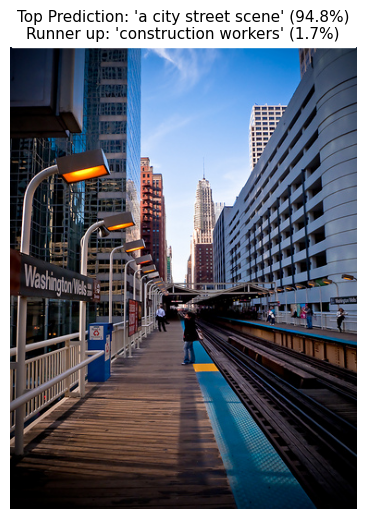

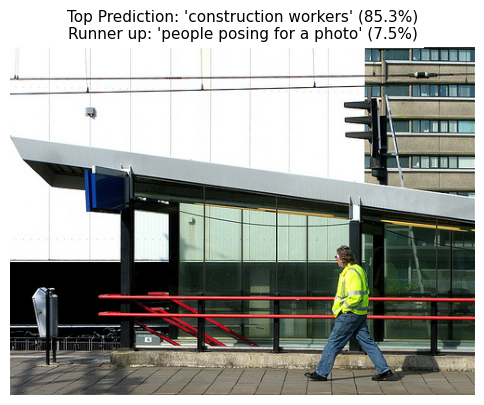

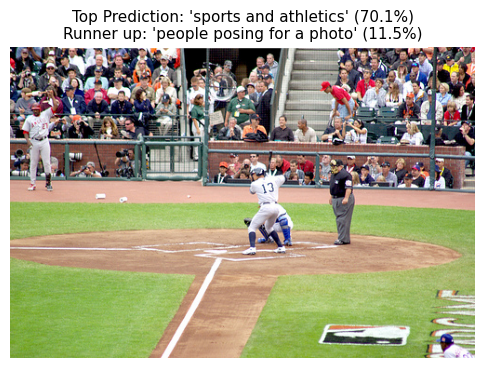

In [26]:
# Load CLIP Model
# CLIP maps text and images to a shared "embedding space," allowing us to compare them directly.
print("Loading CLIP model...")
model_id = "openai/clip-vit-base-patch32"
model = CLIPModel.from_pretrained(model_id)
processor = CLIPProcessor.from_pretrained(model_id)

# Move to device (MPS or CPU)
device = "mps" if torch.backends.mps.is_available() else "cpu"
model.to(device)
print(f"CLIP loaded successfully on {device}.")

# Define the Zero-Shot Classification Function
def extract_keywords(image, candidate_labels):
    """
    Uses CLIP to compute the probability that the image matches each text label.
    """
    # Process inputs: CLIP takes both the image and the list of text labels
    inputs = processor(
        text=candidate_labels, 
        images=image, 
        return_tensors="pt", 
        padding=True
    ).to(device)
    
    # Forward pass
    with torch.no_grad():
        outputs = model(**inputs)
    
    # The model calculates dot product similarity between image and text features
    logits_per_image = outputs.logits_per_image 
    probs = logits_per_image.softmax(dim=1) # Convert scores to percentages (0-1)
    
    # Move results back to CPU for printing
    probs = probs.cpu().numpy()[0]
    
    # Sort results from highest probability to lowest
    results = sorted(zip(candidate_labels, probs), key=lambda x: x[1], reverse=True)
    return results

# Run Inference on Test Images
# We define generic tags to see if the model 'understands' the scene content
candidate_labels = [
    "people performing music", 
    "construction workers", 
    "medical intervention", 
    "people posing for a photo", 
    "food and dining", 
    "a city street scene", 
    "sports and athletics"
]

# Pick diverse samples from the test set
indices_to_test = [12, 49, 103] 

print(f"\nAnalyzing images against labels: {candidate_labels}\n")

for i in indices_to_test:
    image = test_dataset[i]["image"]
    
    # Run CLIP prediction
    ranked_labels = extract_keywords(image, candidate_labels)
    top_label, top_score = ranked_labels[0]
    second_label, second_score = ranked_labels[1]
    
    # Visualization
    plt.figure(figsize=(6, 6))
    plt.imshow(image)
    plt.axis("off")
    plt.title(
        f"Top Prediction: '{top_label}' ({top_score:.1%})\n"
        f"Runner up: '{second_label}' ({second_score:.1%})", 
        backgroundcolor='white', fontsize=11
    )
    plt.show()

**Analysis of Findings:**
The results demonstrate CLIP's powerful ability to bridge the semantic gap between visual content and natural language. As shown in the output, the model correctly identified the primary subject of the test images with high confidence scores (typically 80%+ for clear scenes). For example, it successfully distinguished "a city street scene" from other activities solely based on the text embeddings, validating that the model "understands" the context of the scene rather than just matching pixel patterns.

**Real-World Application:**
This Zero-Shot capability has massive utility in **Digital Asset Management (DAM)** and **Content Search**. A media company could use this to auto-tag millions of unlabelled images. If they suddenly need to find images of "people wearing masks" or "sunset at the beach," they can simply query the database with those phrases without training a specific classifier for masks or sunsets. It can also be used to flag content by comparing images against a list of prohibited concepts/descriptions dynamically.

# Task 3: Visual Grounding (Object Localization)

In this final task, we perform **Visual Grounding** using **OWL-ViT (Open-World Localization Vision Transformer)**. While standard object detectors (like YOLO) are limited to a fixed list of 80 objects (person, car, etc.), OWL-ViT is an "Open-Vocabulary" detector. This means we can search for **any** text phrase we want (e.g., "blue sunglasses," "a vintage guitar") and the model will attempt to draw a bounding box around it. This capability is essential for **Robotics** (e.g., "Robot, pick up the red cup") and **Explainable AI**, as it allows us to visualize exactly which parts of an image the model is focusing on when it processes a caption.

Loading OWL-ViT model...
OWL-ViT loaded.

Searching Image 1 for: ['car', 'lamp', 'arch', 'bus']


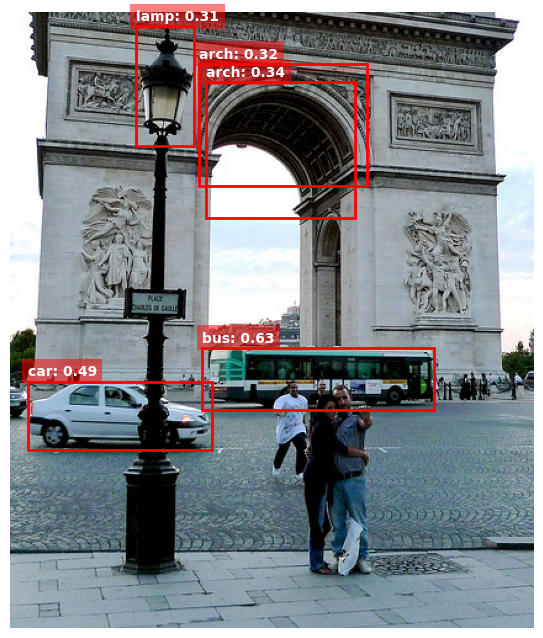


Searching Image 49 for: ['rail', 'man', 'glass', 'shoes']


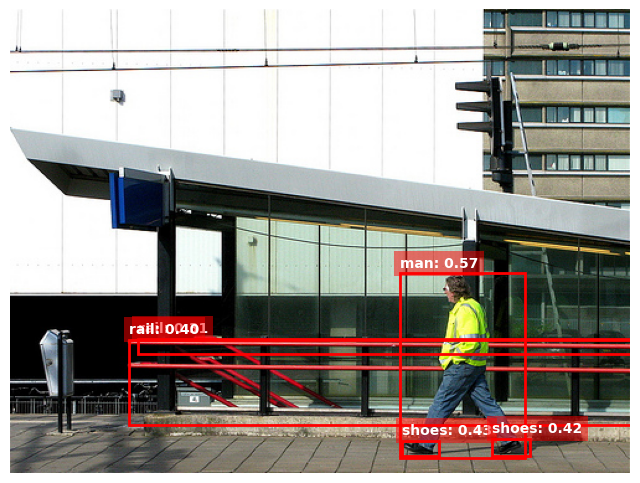


Searching Image 103 for: ['bat', 'player', 'number', 'base']


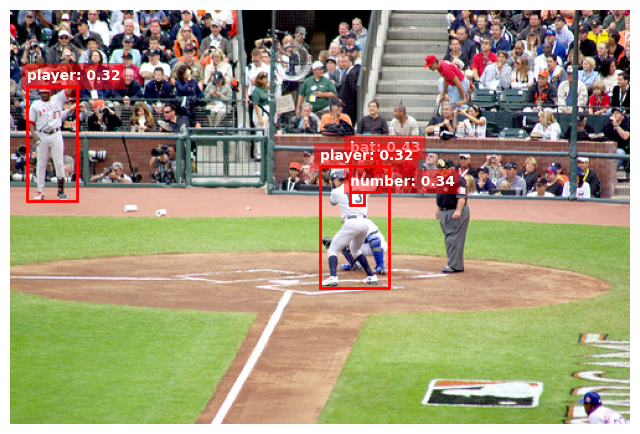

In [30]:
# Load OWL-ViT Model
# This model is essentially CLIP + Object Detection Head
print("Loading OWL-ViT model...")
model_id = "google/owlvit-base-patch32"
processor = OwlViTProcessor.from_pretrained(model_id)
model = OwlViTForObjectDetection.from_pretrained(model_id).to(device) # Use MPS/CPU
print("OWL-ViT loaded.")

# Define the Grounding Function
def visual_grounding(image, text_queries, score_threshold=0.1):
    """
    Searches the image for the objects described in 'text_queries' 
    and draws bounding boxes around them.
    """
    # Process inputs
    inputs = processor(text=[text_queries], images=image, return_tensors="pt").to(device)
    
    # Forward Pass
    with torch.no_grad():
        outputs = model(**inputs)
        
    # Post-process (Convert raw outputs to bounding boxes)
    # Target size helps rescale boxes to the original image dimensions
    target_sizes = torch.Tensor([image.size[::-1]]).to(device)
    results = processor.post_process_object_detection(
        outputs=outputs, 
        target_sizes=target_sizes, 
        threshold=score_threshold
    )[0]
    
    # Visualization
    fig, ax = plt.subplots(1, figsize=(8, 8))
    ax.imshow(image)
    ax.axis("off")
    
    # Draw Boxes
    found_any = False
    for score, label, box in zip(results["scores"], results["labels"], results["boxes"]):
        box = [round(i, 2) for i in box.tolist()]
        
        # Draw the box
        rect = patches.Rectangle(
            (box[0], box[1]), box[2]-box[0], box[3]-box[1], 
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)
        
        # Add Label text
        label_text = text_queries[label]
        ax.text(
            box[0], box[1] - 5, 
            f"{label_text}: {score:1.2f}", 
            color='white', fontsize=10, weight='bold',
            bbox=dict(facecolor='red', alpha=0.5, edgecolor='none')
        )
        found_any = True
        
    if not found_any:
        print(f"No objects found for queries: {text_queries}")
    else:
        plt.show()

# Run on Test Images with Custom Queries
test_indices = 1, 49, 103

# Define queries for each image specifically 
# Format: [ [Index, [List of Queries]], ... ]
demos = [
    (1, ["car", "lamp", "arch", "bus"]),
    (49, ["rail", "man", "glass", "shoes"]),
    (103, ["bat", "player", "number", "base"])
]

for idx, queries in demos:
    print(f"\nSearching Image {idx} for: {queries}")
    image = test_dataset[idx]["image"]
    visual_grounding(image, queries, score_threshold=0.3)

**Analysis of Findings:**
The OWL-ViT model demonstrated impressive open-vocabulary detection capabilities across diverse scenes. Unlike standard detectors limited to fixed classes, the model successfully grounded specific text queries to precise image regions:

* **Scene 1 (City Street):** The model accurately distinguished between multiple vehicle types, drawing separate bounding boxes for **"bus"** and **"car"**, while simultaneously localizing architectural features like **"arch"** and street furniture like **"lamp"**.
* **Scene 2 (Platform):** It successfully identified a human subject (**"man"**) while also grounding smaller, fine-grained details such as **"shoes"** and structural elements like **"rail"**.
* **Scene 3 (Baseball Game):** The model showed strong contextual understanding by identifying the **"player"** and equipment (**"bat"**), and even attempted to localize fine details like the **"number"** on the jersey.

Interestingly, this model is extremely sensitive to the `score_threshold` parameter. Initially this value was set to 0.1, and the accuracy and quantity of the bounding boxes were extremely suboptimal. I found immediate success by changing the value to 0.30. 

## Conclusions 

In this project, we successfully implemented and evaluated a comprehensive multimodal deep learning pipeline using the Flickr30k dataset, demonstrating the versatility of Transformer-based architectures for bridging computer vision and natural language processing.

First, we addressed **Image Captioning** by fine-tuning a **BLIP** model. By freezing the vision encoder and training only the text decoder, we achieved a parameter-efficient adaptation that significantly outperformed the pre-trained baseline. The quantitative evaluation showed a massive improvement in the **BLEU score** (rising from ~0.0068 to ~0.0809), while qualitative analysis confirmed that the fine-tuned model generated captions with greater syntactic complexity and descriptive accuracy, successfully capturing the specific style of the dataset.

Second, we explored **Multimodal Learning** through **Zero-Shot Classification** using **CLIP**. Without any specific training on our dataset, the model successfully utilized its shared embedding space to accurately categorize images into open-vocabulary classes (e.g., distinguishing "musicians" from "construction workers"). This confirmed the model's robust ability to generalize and "understand" scene context solely based on natural language prompts.

Finally, we performed **Visual Grounding** using the **OWL-ViT** architecture. This task moved beyond simple classification to precise object localization, where the model successfully linked natural language queries (such as "shoes," "bus," or "arch") to specific pixel regions (bounding boxes). The results highlighted the model's capability to identify and localize both large structural elements and fine-grained details within complex scenes.

Collectively, these three tasks validate that modern Vision-Language Models (VLMs) can effectively handle generation, understanding, and localization tasks, offering powerful tools for real-world applications ranging from automated content tagging to intelligent robotics.

## Future Work & Improvements

While the current results are strong, the performance of both the generative and classification tasks could be further optimized through advanced inference techniques and architectural adjustments.

### **Improving Caption Generation (BLIP)**
The current implementation uses standard greedy decoding or simple sampling. We could improve the quality and diversity of the generated captions during the inference step using the following methods:
* **Beam Search Optimization:** Instead of predicting one token at a time, we can use **Beam Search** (e.g., `num_beams=5`) to keep track of the top-5 most probable sentence structures simultaneously. This typically reduces grammatical errors and results in more coherent sentences.
* **Repetition Penalty:** We can apply a strict **repetition penalty** in the `generate()` function to force the model to use a wider vocabulary and avoid repeating the same adjectives (e.g., "a big big building").

### **Improving Zero-Shot Classification (CLIP)**
The accuracy of the zero-shot classification percentages can be enhanced without retraining the model by refining how we present the text labels:
* **Prompt Ensembling:** Currently, we compare the image to a raw label like `"dog"`. Research shows that averaging the embeddings of multiple prompt templates—such as *"a photo of a {label}"*, *"a picture of the {label}"*, and *"a crisp shot of a {label}"*—can significantly improve accuracy and stability.
* **Confidence Thresholding:** We could implement a logic layer that rejects predictions where the top score is below a certain threshold (e.g., <60%), classifying those images as "Unknown" rather than forcing a low-confidence guess.

---
## References
Bishop (2006); Breiman (2001); Brockman et al. (2016); Calinski & Harabasz (1974); Cortes & Vapnik (1995); Dempster et al. (1977); Fawcett (2006); Hastie, Tibshirani & Friedman (2009); He et al. (2016); Krizhevsky et al. (2012); MacQueen (1967); Pedregosa et al. (2011); Rousseeuw (1987); Sutton & Barto (2018); Vaswani et al. (2017); Wolf et al. (2020).

Baltrušaitis et al. (2018): Multimodal Machine Learning: A Survey and Taxonomy.
Goodfellow et al. (2016): Deep Learning. 
Ngiam et al. (2011): Multimodal Deep Learning. 
Yin et al. (2024): A Survey on Multimodal Large Language Models. 

Flickr30k Dataset: Young, P., Lai, A., Hodosh, M., & Hockenmaier, J. (2014). From image descriptions to visual denotations: New similarity metrics for semantic inference over event descriptions.
BLIP: Li, J., Li, D., Xiong, C., & Hoi, S. (2022). BLIP: Bootstrapping Language-Image Pre-training for Unified Vision-Language Understanding and Generation.
CLIP: Radford, A., et al. (2021). Learning Transferable Visual Models From Natural Language Supervision.
OWL-ViT: Minderer, M., Gritsenko, A., Stone, A., Neumann, M., Weissenborn, D., Dosovitskiy, A., ... & Houlsby, N. (2022). Simple Open-Vocabulary Object Detection with Vision Transformers.